# Step 6: Visualizations
### Marketing Funnel Analysis: Bank Marketing Campaign Dataset

### Charts We'll Build
1. Funnel chart (overall drop-off)
2. Conversion by channel (bar chart)
3. Conversion by job type (horizontal bar)
4. Conversion by age group (bar chart)
5. Conversion by month (line chart)
6. Conversion by campaign intensity (bar chart)
7. Previous outcome impact (bar chart)
8. Heatmap: Job × Channel

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/bank_cleaned.csv')
print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Data loaded: 41,188 rows × 23 columns


In [12]:
funnel_data = {
    'Stage': [
        '1. Total Contacts',
        '2. Previously Contacted',
        '3. Engaged',
        '4. Converted'
    ],
    'Count': [41188, 5625, 41184, 4640]
}

fig = go.Figure(go.Funnel(
    y=funnel_data['Stage'],
    x=funnel_data['Count'],
    textinfo='value+percent initial',
    marker=dict(color=['#2196F3', '#4CAF50', '#FF9800', '#F44336']),
    connector=dict(line=dict(color='royalblue', width=2))
))

fig.update_layout(
    title='Marketing Funnel: Overall Conversion',
    title_font_size=20,
    width=800, height=500
)

fig.write_html('../outputs/01_funnel_chart.html')
fig.show()
print("Saved: 01_funnel_chart.html")

Saved: 01_funnel_chart.html


In [13]:
channel_data = pd.DataFrame({
    'Channel': ['Cellular', 'Telephone'],
    'Conversion Rate': [14.74, 5.23],
    'Drop-off Rate': [85.26, 94.77]
})

fig = go.Figure()
fig.add_trace(go.Bar(
    name='Conversion Rate %',
    x=channel_data['Channel'],
    y=channel_data['Conversion Rate'],
    marker_color=['#4CAF50', '#F44336'],
    text=channel_data['Conversion Rate'].apply(lambda x: f'{x}%'),
    textposition='outside'
))

fig.update_layout(
    title='Conversion Rate by Contact Channel',
    yaxis_title='Conversion Rate (%)',
    xaxis_title='Channel',
    title_font_size=20,
    width=700, height=500
)

fig.write_html('../outputs/02_channel_conversion.html')
fig.show()
print("Saved: 02_channel_conversion.html")

Saved: 02_channel_conversion.html


In [14]:
job_seg = pd.read_csv('../outputs/segment_job.csv')
job_seg = job_seg.sort_values('conversion_rate_%', ascending=True)

fig = go.Figure(go.Bar(
    x=job_seg['conversion_rate_%'],
    y=job_seg['job'],
    orientation='h',
    marker=dict(
        color=job_seg['conversion_rate_%'],
        colorscale='RdYlGn',
        showscale=True
    ),
    text=job_seg['conversion_rate_%'].apply(lambda x: f'{x}%'),
    textposition='outside'
))

fig.update_layout(
    title='Conversion Rate by Job Type',
    xaxis_title='Conversion Rate (%)',
    yaxis_title='Job Type',
    title_font_size=20,
    width=800, height=550
)

fig.write_html('../outputs/03_job_conversion.html')
fig.show()
print("Saved: 03_job_conversion.html")

Saved: 03_job_conversion.html


In [15]:
age_seg = pd.read_csv('../outputs/segment_age.csv')
age_order = ['17-25', '26-35', '36-45', '46-55', '56-65', '65+']
age_seg['age_group'] = pd.Categorical(age_seg['age_group'], categories=age_order, ordered=True)
age_seg = age_seg.sort_values('age_group')

fig = go.Figure(go.Bar(
    x=age_seg['age_group'],
    y=age_seg['conversion_rate_%'],
    marker=dict(
        color=age_seg['conversion_rate_%'],
        colorscale='Blues',
        showscale=True
    ),
    text=age_seg['conversion_rate_%'].apply(lambda x: f'{x}%'),
    textposition='outside'
))

fig.update_layout(
    title='Conversion Rate by Age Group',
    xaxis_title='Age Group',
    yaxis_title='Conversion Rate (%)',
    title_font_size=20,
    width=800, height=500
)

fig.write_html('../outputs/04_age_conversion.html')
fig.show()
print("Saved: 04_age_conversion.html")

Saved: 04_age_conversion.html


In [16]:
month_seg = pd.read_csv('../outputs/segment_month.csv')
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']
month_seg['month'] = pd.Categorical(month_seg['month'], categories=month_order, ordered=True)
month_seg = month_seg.sort_values('month')

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=month_seg['month'],
    y=month_seg['conversion_rate_%'],
    mode='lines+markers+text',
    text=month_seg['conversion_rate_%'].apply(lambda x: f'{x}%'),
    textposition='top center',
    marker=dict(size=10, color='#2196F3'),
    line=dict(width=3, color='#2196F3')
))

fig.update_layout(
    title='Conversion Rate by Month',
    xaxis_title='Month',
    yaxis_title='Conversion Rate (%)',
    title_font_size=20,
    width=900, height=500
)

fig.write_html('../outputs/05_month_conversion.html')
fig.show()
print("Saved: 05_month_conversion.html")

Saved: 05_month_conversion.html


In [17]:
campaign_data = pd.DataFrame({
    'Contacts': ['1 contact', '2-3 contacts', '4-5 contacts', '6+ contacts'],
    'Conversion Rate': [13.04, 11.22, 8.68, 5.49]
})

fig = go.Figure(go.Bar(
    x=campaign_data['Contacts'],
    y=campaign_data['Conversion Rate'],
    marker_color=['#4CAF50', '#8BC34A', '#FF9800', '#F44336'],
    text=campaign_data['Conversion Rate'].apply(lambda x: f'{x}%'),
    textposition='outside'
))

fig.update_layout(
    title='Conversion Rate by Campaign Intensity (Less is More)',
    xaxis_title='Number of Contacts',
    yaxis_title='Conversion Rate (%)',
    title_font_size=20,
    width=800, height=500
)

fig.write_html('../outputs/06_campaign_intensity.html')
fig.show()
print("Saved: 06_campaign_intensity.html")

Saved: 06_campaign_intensity.html


In [18]:
poutcome_data = pd.DataFrame({
    'Previous Outcome': ['Success', 'Failure', 'No Previous Contact'],
    'Conversion Rate': [65.11, 14.23, 8.83]
})

fig = go.Figure(go.Bar(
    x=poutcome_data['Previous Outcome'],
    y=poutcome_data['Conversion Rate'],
    marker_color=['#4CAF50', '#FF9800', '#F44336'],
    text=poutcome_data['Conversion Rate'].apply(lambda x: f'{x}%'),
    textposition='outside'
))

fig.update_layout(
    title='Conversion Rate by Previous Campaign Outcome',
    xaxis_title='Previous Outcome',
    yaxis_title='Conversion Rate (%)',
    title_font_size=20,
    width=800, height=500
)

fig.write_html('../outputs/07_previous_outcome.html')
fig.show()
print("Saved: 07_previous_outcome.html")

Saved: 07_previous_outcome.html


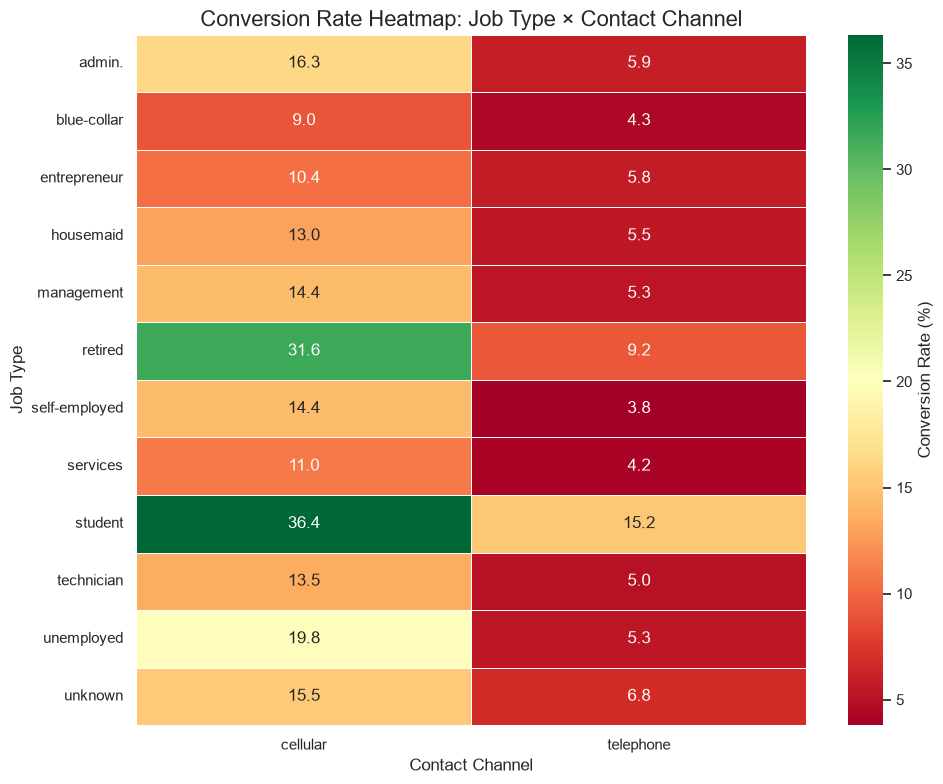

Saved: 08_heatmap_job_channel.png


In [19]:
heatmap_data = df.groupby(['job', 'contact'], observed=True)['y_binary'].mean() * 100
heatmap_pivot = heatmap_data.unstack().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Conversion Rate (%)'}
)
plt.title('Conversion Rate Heatmap: Job Type × Contact Channel', fontsize=16)
plt.xlabel('Contact Channel')
plt.ylabel('Job Type')
plt.tight_layout()
plt.savefig('../outputs/08_heatmap_job_channel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_heatmap_job_channel.png")

## Visualization Summary
- Funnel chart shows dramatic drop from Stage 1 to Stage 2
- Cellular channel clearly dominates telephone
- Students and retired have highest job conversion rates
- 65+ age group is the highest converting age segment
- March is the best performing month by far
- Previous campaign success is the single strongest predictor
- Heatmap reveals best job × channel combinations